### Downstream analysis KAIJU, module: tax_classification_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p kaiju
```

In [23]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)
library(microbiome)
library(svglite)
options(readr.show_col_types = FALSE)

In [24]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [25]:
read_kaiju <- function(level) {
  otu <- as.data.frame(read_delim(paste0("../tables/gm_gathering/kaiju/",level,"_reads.tsv"), 
  delim = "\t"
  ))
  otu$ID <- paste0("ID", seq_len(nrow(otu)))
  
  taxa <- otu[, c("ID", level)]
  colnames(taxa) <- c("ID", "Taxa_level")
  
  rownames(taxa) <- taxa$ID
  taxa <- taxa %>%
    mutate(
      Taxa_level = str_remove(Taxa_level, ";$"),
      Taxa_level = case_when(
        Taxa_level %in% c(
          "unclassified",
          "Viruses",
          paste0("cannot be assigned to a (non-viral) ", level)
        ) ~ paste(Taxa_level, Taxa_level, Taxa_level, Taxa_level, Taxa_level, sep = ";"),
        TRUE ~ Taxa_level
      )
    ) %>%
    separate(
      Taxa_level,
      into = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"),
      sep = ";",
      fill = "right"
    )
  
  taxa$ID <- NULL
  
  rownames(otu) <- otu$ID
  otu$ID <- NULL
  otu[[level]] <- NULL

  return(list(otu=otu, taxa=taxa))
}

In [26]:
output_dir <- "../figures/kaiju/"
env <- as.data.frame(read_delim("../tables/cr18_env_geomosaicPlot.csv", 
                  delim = ",",
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))
                  
rownames(env) <- env$Geomosaic_sample
env$Geomosaic_sample <- NULL
                  

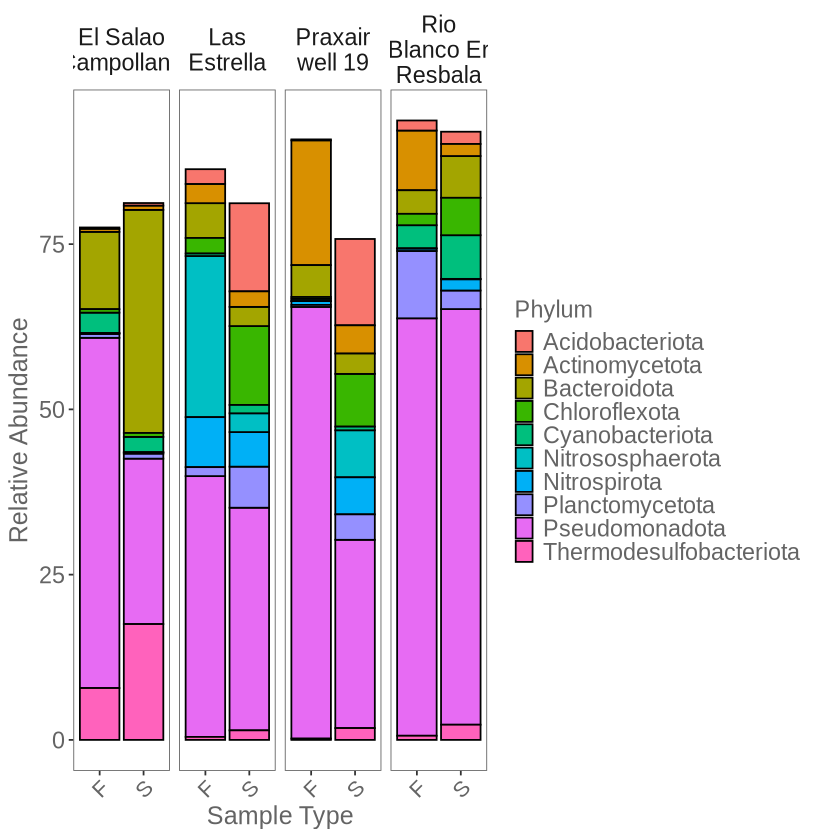

In [ ]:
# ── PHYLUM ──────────────────────────────────────────────────────────────────
level <- "phylum"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) phylum")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.phylum <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
phylum.top10.ra <- prune_taxa(names(top10.phylum), prok_ndata_ra)

plot_bar(phylum.top10.ra, x = "Geomosaic_sample_type", fill = "Phylum") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 14),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 14, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 14),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_phylum.svg"), width = 8, height = 12, dpi = 300)

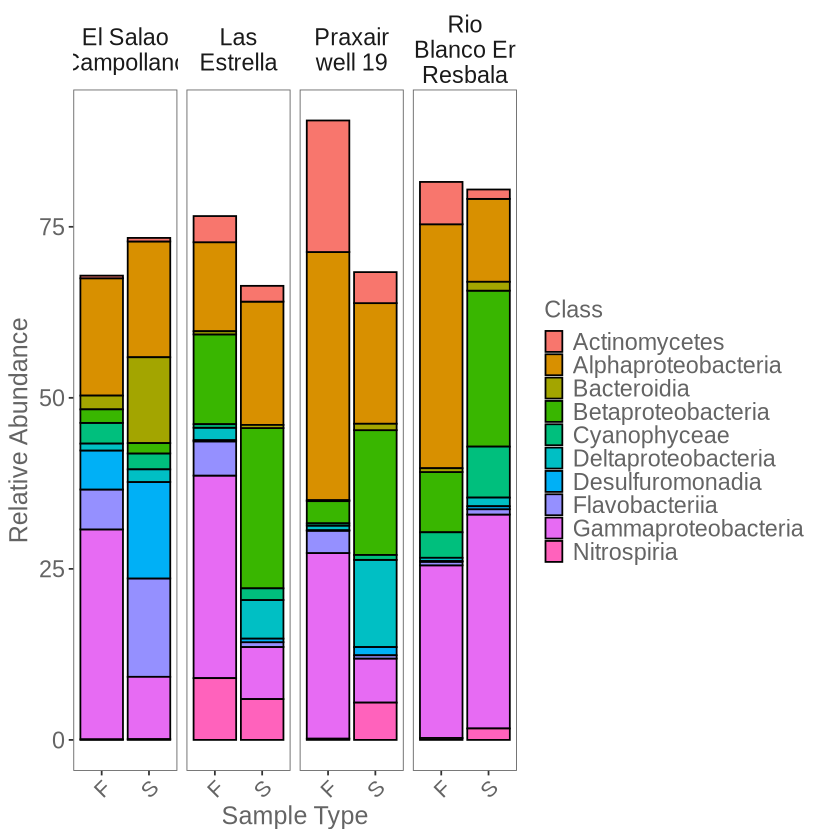

In [35]:
# ── CLASS ────────────────────────────────────────────────────────────────────
level <- "class"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) class")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.class <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
class.top10.ra <- prune_taxa(names(top10.class), prok_ndata_ra)

plot_bar(class.top10.ra, x = "Geomosaic_sample_type", fill = "Class") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 14),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 14, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 14),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_class.svg"), width = 12, height = 8, dpi = 300)

In [ ]:
plot_bar(class.top10.ra, x = "Geomosaic_sample_type", fill = "Class") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_class_2.svg"), width = 12, height = 8, dpi = 300)

ERROR: Error in parse(text = input): <text>:18:1: unexpected symbol
17: 
18: ggsave
    ^


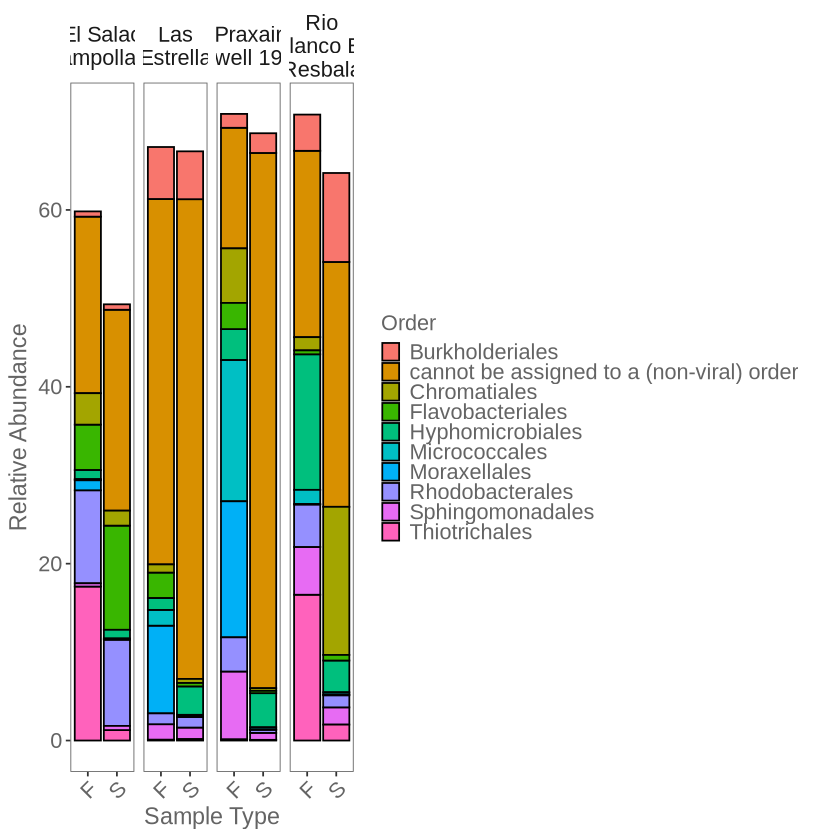

In [ ]:
# ── ORDER ──────────────────────────────────────────────────────────────────
level <- "order"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa


# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)


prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100 )

N <- 10
top10.order <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
order.top10.ra <- prune_taxa(names(top10.order), prok_ndata_ra)

plot_bar(order.top10.ra, x = "Geomosaic_sample_type", fill = "Order") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_order.svg"), width = 12, height = 8, dpi = 300)

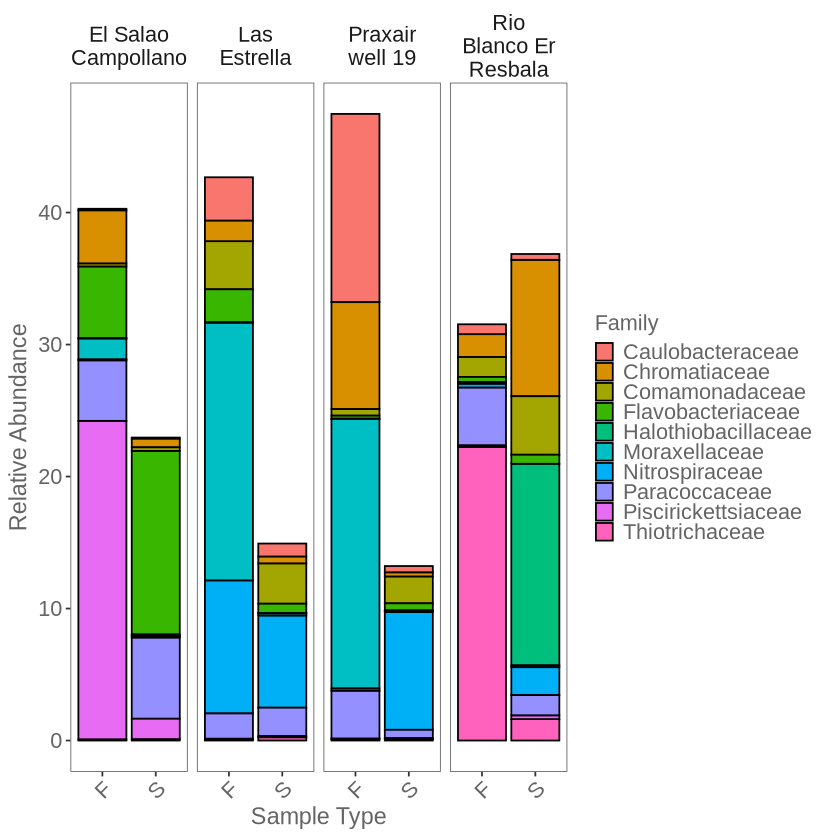

In [ ]:
# ── FAMILY ───────────────────────────────────────────────────────────────────
level <- "family"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.family <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
family.top10.ra <- prune_taxa(names(top10.family), prok_ndata_ra)

plot_bar(family.top10.ra, x = "Geomosaic_sample_type", fill = "Family") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right"
  )

  ggsave(paste0(output_dir,  "kaiju_family.svg"), width = 12, height = 8, dpi = 300)

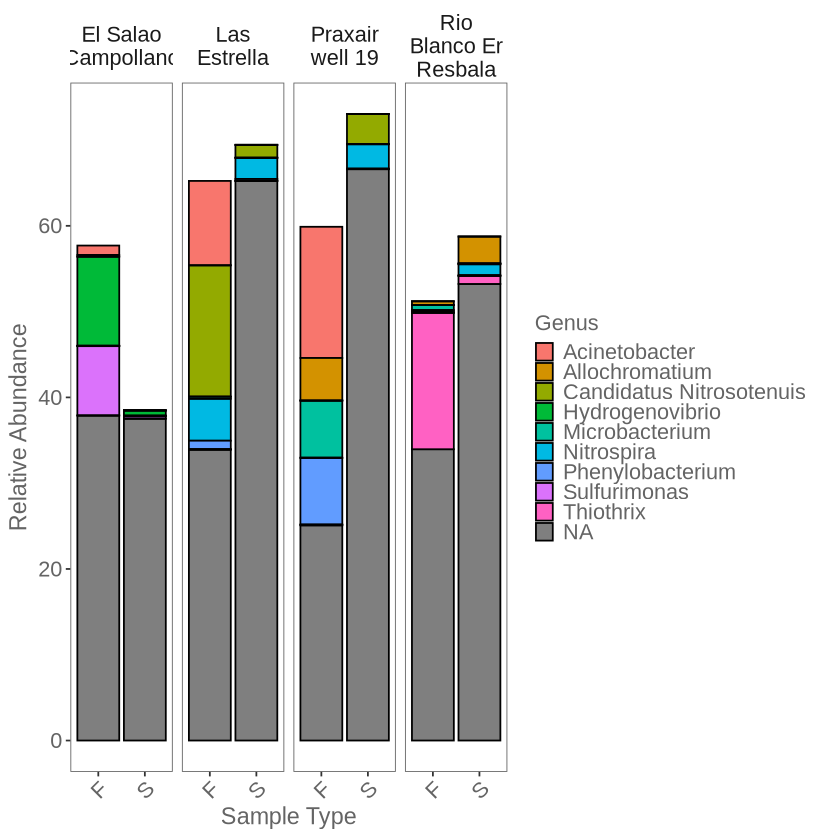

In [ ]:
# ── GENUS ──────────────────────────────────────────────────────────────────
level <- "genus"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) species")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.genus <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
genus.top10.ra <- prune_taxa(names(top10.genus), prok_ndata_ra)

plot_bar(genus.top10.ra, x = "Geomosaic_sample_type", fill = "Genus") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
 theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 13),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 13, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 13),
    legend.text       = element_text(size = 13),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_genus.svg"), width = 12, height = 8, dpi = 300)

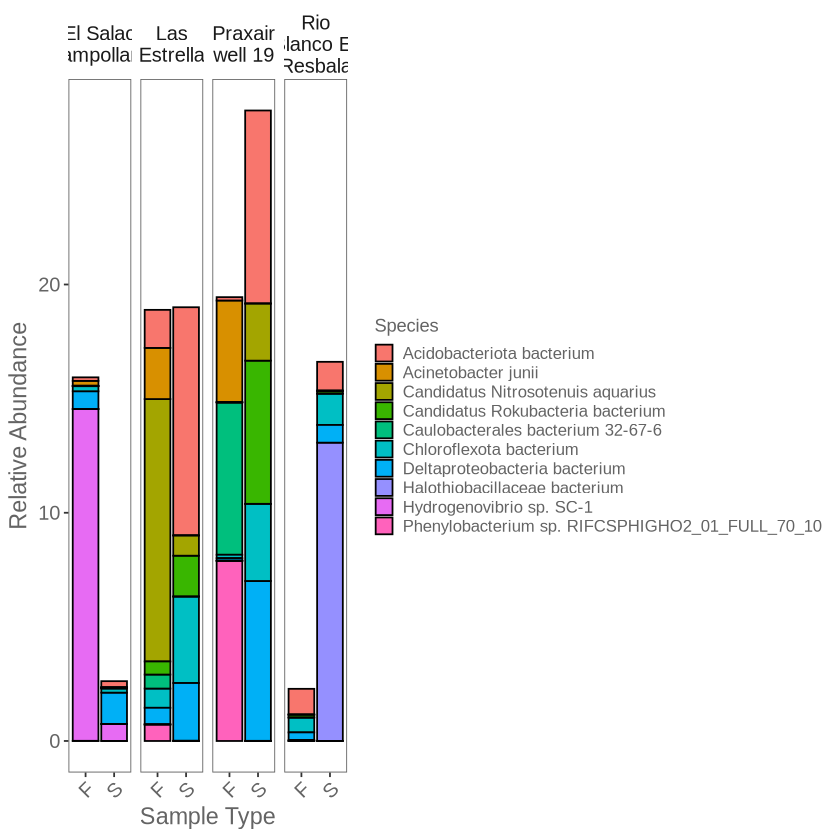

In [ ]:
# ── SPECIES ──────────────────────────────────────────────────────────────────
level <- "species"
payload <- read_kaiju(level)
otu <- payload$otu
taxa <- payload$taxa

phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) species")))
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100)

N <- 10
top10.species <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
species.top10.ra <- prune_taxa(names(top10.species), prok_ndata_ra)

plot_bar(species.top10.ra, x = "Geomosaic_sample_type", fill = "Species") +
  facet_grid(~site_name, scales = "free", space = "free",
             labeller = labeller(site_name = label_wrap_gen(width = 10))) +
  labs(x = "Sample Type", y = "Relative Abundance") +
  theme_glab() +
  theme(
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "right"
  )

ggsave(paste0(output_dir, "kaiju_species.svg"), width = 12, height = 8, dpi = 300)

In [ ]:
# ── NMDS ─────────────────────────────────────────────────────────────────────

# Normalise counts (median-ratio scaling)
prok_ndata <- transform_sample_counts(
  prok,
  function(x) (x / sum(x)) * median(microbiome::readcount(prok))
)

# Glom at Family and convert to relative abundance
prok_nmds <- prok_ndata %>%
  tax_glom("Family") %>%
  transform_sample_counts(function(x) x / sum(x))

# Weighted Bray-Curtis
nmds_w  <- distance(prok_nmds, method = "bray")
ord_w   <- ordinate(prok_nmds, nmds_w,  method = "NMDS", trymax = 1000)

# Unweighted (binary) Bray-Curtis
nmds_uw <- distance(prok_nmds, method = "bray", binary = TRUE)
ord_uw  <- ordinate(prok_nmds, nmds_uw, method = "NMDS", trymax = 1000)


Run 0 stress 0.04940863 
Run 1 stress 0.04940863 
... Procrustes: rmse 1.184421e-05  max resid 2.223861e-05 
... Similar to previous best
Run 2 stress 0.0893341 
Run 3 stress 0.0893341 
Run 4 stress 0.08991866 
Run 5 stress 0.04940863 
... Procrustes: rmse 1.269013e-05  max resid 2.344308e-05 
... Similar to previous best
Run 6 stress 0.0893341 
Run 7 stress 0.2140678 
Run 8 stress 0.04940863 
... Procrustes: rmse 2.146278e-06  max resid 3.697532e-06 
... Similar to previous best
Run 9 stress 0.04940863 
... Procrustes: rmse 3.221319e-06  max resid 5.917265e-06 
... Similar to previous best
Run 10 stress 0.04940863 
... Procrustes: rmse 6.820082e-06  max resid 1.290743e-05 
... Similar to previous best
Run 11 stress 0.04940863 
... Procrustes: rmse 2.383825e-06  max resid 3.528481e-06 
... Similar to previous best
Run 12 stress 0.08991866 
Run 13 stress 0.04940863 
... Procrustes: rmse 2.17324e-06  max resid 3.467791e-06 
... Similar to previous best
Run 14 stress 0.2400219 
Run 15 str

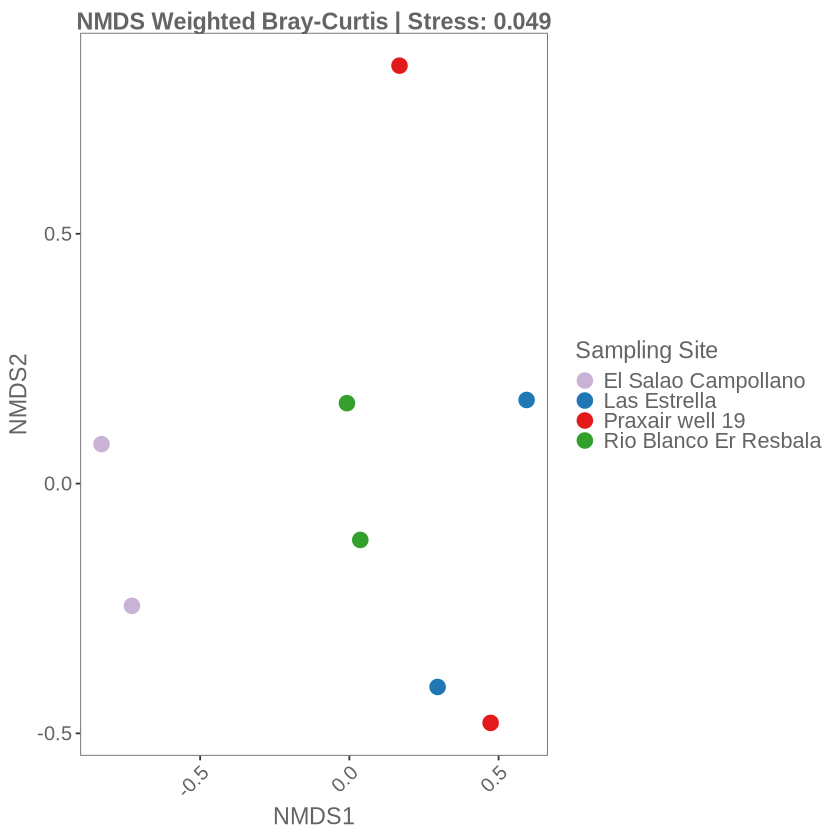

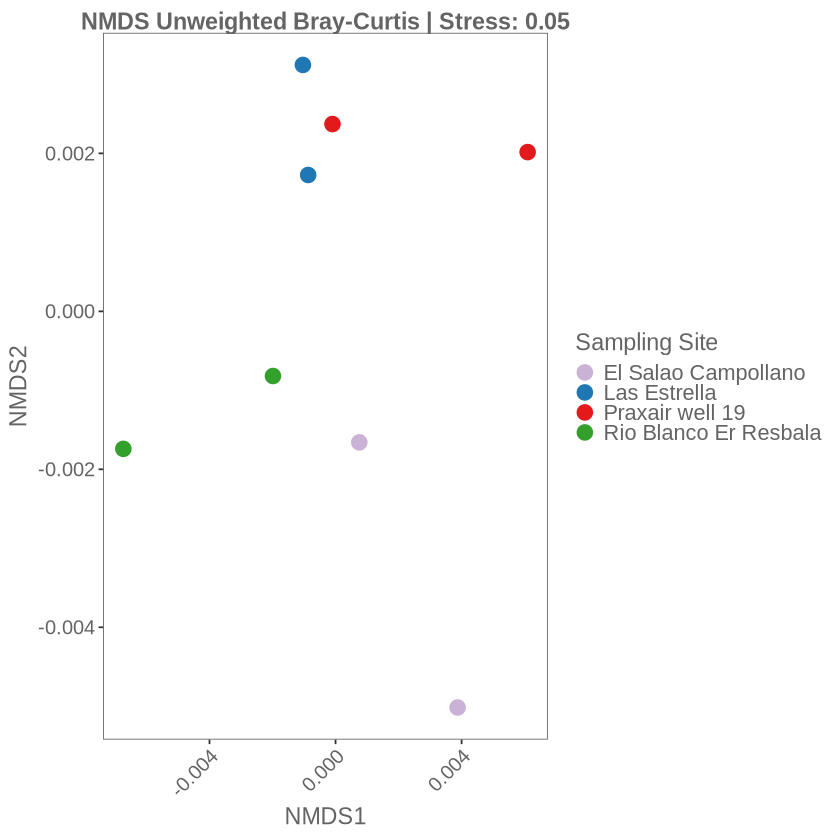

In [ ]:

# --- Palette fissa per i biomi ---
biome_colors <- c(
"#cab2d6",
"#1F78B4",  # blu
"#e31a1c",
"#33a02c"  # verde
)


# Plot weighted
plot_ordination(
  prok_nmds, ord_w,
  type  = "samples",
  title = paste0("NMDS Weighted Bray-Curtis | Stress: ", round(ord_w$stress, 3)),
  color = "site_name"          # ← match exactly your sample_data column name
) +
scale_color_manual(values = biome_colors) +
geom_point(size = 4) +   # ← overrides visually with bigger points
labs(color = "Sampling Site") +  # ← ADD THIS LINE WITH YOUR CUSTOM TITLE
theme_glab() +
theme(
    plot.title        = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 13),
    legend.position   = "right"
  )
ggsave(paste0(output_dir, "nmds_weighted.svg"), width = 8, height = 12, dpi = 300)
# Plot unweighted
plot_ordination(
  prok_nmds, ord_uw,
  type  = "samples",
  title = paste0("NMDS Unweighted Bray-Curtis | Stress: ", round(ord_uw$stress, 3)),
  color = "site_name"
) +
scale_color_manual(values = biome_colors) +
geom_point(size = 4) +   # ← overrides visually with bigger points
labs(color = "Sampling Site") +  # ← ADD THIS LINE WITH YOUR CUSTOM TITLE
theme_glab() +
theme(
    plot.title        = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 12),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 14),
    strip.text.x      = element_text(size = 12, margin = margin(t = 2, b = 2)),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 14),
    legend.text       = element_text(size = 13),
    legend.position   = "right"
  )
ggsave(paste0(output_dir, "nmds_unweighted.svg"), width = 8, height = 12, dpi = 300)